In [1]:
import pandas as pd

df = pd.read_csv("sales.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.columns.tolist())

Rows: 4248
Columns: 20
['Area Code', 'State', 'Market', 'Market Size', 'Profit', 'Margin', 'Sales', 'COGS', 'Total Expenses', 'Marketing', 'Inventory', 'Budget Profit', 'Budget COGS', 'Budget Margin', 'Budget Sales', 'ProductId', 'Date', 'Product Type', 'Product', 'Type']


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4248 entries, 0 to 4247
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Area Code       4248 non-null   int64 
 1   State           4248 non-null   object
 2   Market          4248 non-null   object
 3   Market Size     4248 non-null   object
 4   Profit          4248 non-null   int64 
 5   Margin          4248 non-null   int64 
 6   Sales           4248 non-null   int64 
 7   COGS            4248 non-null   int64 
 8   Total Expenses  4248 non-null   int64 
 9   Marketing       4248 non-null   int64 
 10  Inventory       4248 non-null   int64 
 11  Budget Profit   4248 non-null   int64 
 12  Budget COGS     4248 non-null   int64 
 13  Budget Margin   4248 non-null   int64 
 14  Budget Sales    4248 non-null   int64 
 15  ProductId       4248 non-null   int64 
 16  Date            4248 non-null   object
 17  Product Type    4248 non-null   object
 18  Product 

Understand the Budget vs Actual Columns

1. Sales Variance

Sales Variance = Sales − Budget Sales

2.Sales Variance %

Sales Variance % = (Sales − Budget Sales) / Budget Sales × 100

In [3]:
df[[
    "Sales",
    "Budget Sales",
    "Profit",
    "Budget Profit",
    "COGS",
    "Budget COGS",
    "Margin",
    "Budget Margin"
]].head(10)

,Sales,Budget Sales,Profit,Budget Profit,COGS,Budget COGS,Margin,Budget Margin
0,292,270,107,110,116,110,176,160
1,225,210,75,90,90,80,135,130
2,325,290,122,130,130,110,195,180
3,289,260,105,110,115,100,174,160
4,223,210,104,90,90,80,135,130
5,223,210,104,90,90,80,135,130
6,275,240,135,110,103,90,155,150
7,334,260,171,130,125,100,188,160
8,346,290,181,130,130,110,195,180
9,51,50,15,20,20,20,31,30


In [4]:
df[[
    "Sales",
    "Budget Sales",
    "Profit",
    "Budget Profit",
    "COGS",
    "Budget COGS",
    "Margin",
    "Budget Margin"
]].isnull().sum()

Sales            0
Budget Sales     0
Profit           0
Budget Profit    0
COGS             0
Budget COGS      0
Margin           0
Budget Margin    0
dtype: int64

Calculate Variance

In [5]:
df["Sales Variance"] = df["Sales"] - df["Budget Sales"]

In [6]:
df["Sales Variance %"] = (
    df["Sales Variance"] / df["Budget Sales"]
) * 100

In [7]:
df[[
    "Sales",
    "Budget Sales",
    "Sales Variance",
    "Sales Variance %"
]].head(10)

,Sales,Budget Sales,Sales Variance,Sales Variance %
0,292,270,22,8.148148
1,225,210,15,7.142857
2,325,290,35,12.068966
3,289,260,29,11.153846
4,223,210,13,6.190476
5,223,210,13,6.190476
6,275,240,35,14.583333
7,334,260,74,28.461538
8,346,290,56,19.310345
9,51,50,1,2.000000


Calculate Profit Variance too

In [8]:
df["Profit Variance"] = df["Profit"] - df["Budget Profit"]

df["Profit Variance %"] = (
    df["Profit Variance"] / df["Budget Profit"]
) * 100

In [9]:
df[[
    "Profit",
    "Budget Profit",
    "Profit Variance",
    "Profit Variance %"
]].head(10)

,Profit,Budget Profit,Profit Variance,Profit Variance %
0,107,110,-3,-2.727273
1,75,90,-15,-16.666667
2,122,130,-8,-6.153846
3,105,110,-5,-4.545455
4,104,90,14,15.555556
5,104,90,14,15.555556
6,135,110,25,22.727273
7,171,130,41,31.538462
8,181,130,51,39.230769
9,15,20,-5,-25.000000


Identify Material Gaps

Step 1 — Find the largest Sales variances

In [10]:
largest_sales_gaps = (
    df.assign(
        Absolute_Sales_Variance=df["Sales Variance"].abs()
    )
    .sort_values(
        "Absolute_Sales_Variance",
        ascending=False
    )
)

largest_sales_gaps[[
    "Date",
    "Market",
    "State",
    "Product",
    "Sales",
    "Budget Sales",
    "Sales Variance",
    "Sales Variance %"
]].head(10)

,Date,Market,State,Product,Sales,Budget Sales,Sales Variance,Sales Variance %
3352,10-01-2011 00:00,West,Nevada,Darjeeling,637,290,347,119.655172
2498,10-01-2010 00:00,West,California,Columbian,650,960,-310,-32.291667
2786,10-01-2010 00:00,West,Nevada,Darjeeling,598,290,308,106.206897
3529,10-01-2010 00:00,Central,Illinois,Caffe Mocha,598,890,-292,-32.808989
3368,10-01-2011 00:00,West,Nevada,Earl Grey,509,230,279,121.304348
3582,10-01-2011 00:00,West,California,Columbian,693,960,-267,-27.812500
2224,10-01-2011 00:00,East,New York,Lemon,547,290,257,88.620690
2546,12-01-2011 00:00,East,New York,Lemon,796,540,256,47.407407
544,10-01-2011 00:00,Central,Illinois,Caffe Mocha,637,890,-253,-28.426966
3905,10-01-2010 00:00,South,Texas,Columbian,520,770,-250,-32.467532


Step 2 — Find the largest Profit variances

In [11]:
largest_profit_gaps = (
    df.assign(
        Absolute_Profit_Variance=df["Profit Variance"].abs()
    )
    .sort_values(
        "Absolute_Profit_Variance",
        ascending=False
    )
)

largest_profit_gaps[[
    "Date",
    "Market",
    "State",
    "Product",
    "Profit",
    "Budget Profit",
    "Profit Variance",
    "Profit Variance %"
]].head(10)

,Date,Market,State,Product,Profit,Budget Profit,Profit Variance,Profit Variance %
2728,10-01-2011 00:00,West,Nevada,Green Tea,-539,-170,-369,217.058824
3275,09-01-2011 00:00,West,Nevada,Green Tea,-638,-280,-358,127.857143
3269,01-01-2011 00:00,West,Nevada,Green Tea,-552,-240,-312,130.000000
3274,08-01-2011 00:00,West,Nevada,Green Tea,-558,-260,-298,114.615385
2726,04-01-2011 00:00,West,Nevada,Green Tea,-542,-250,-292,116.800000
3270,02-01-2011 00:00,West,Nevada,Green Tea,-508,-220,-288,130.909091
3277,12-01-2011 00:00,West,Nevada,Green Tea,-605,-320,-285,89.062500
2727,05-01-2011 00:00,West,Nevada,Green Tea,-524,-250,-274,109.600000
3273,07-01-2011 00:00,West,Nevada,Green Tea,-522,-250,-272,108.800000
3271,03-01-2011 00:00,West,Nevada,Green Tea,-505,-240,-265,110.416667


Market-Level Budget vs Actual

Step 1 — Sales by Market

In [12]:
market_sales = (
    df.groupby("Market")
    .agg(
        Actual_Sales=("Sales", "sum"),
        Budget_Sales=("Budget Sales", "sum")
    )
    .reset_index()
)

market_sales["Sales Variance"] = (
    market_sales["Actual_Sales"]
    - market_sales["Budget_Sales"]
)

market_sales["Sales Variance %"] = (
    market_sales["Sales Variance"]
    / market_sales["Budget_Sales"]
) * 100

market_sales = market_sales.round(2)

market_sales

,Market,Actual_Sales,Budget_Sales,Sales Variance,Sales Variance %
0,Central,265045,250360,14685,5.87
1,East,178576,157900,20676,13.09
2,South,103926,98200,5726,5.83
3,West,272264,239700,32564,13.59


Step 2 — Sort by variance

In [13]:
market_sales.sort_values(
    "Sales Variance",
    ascending=False
)

,Market,Actual_Sales,Budget_Sales,Sales Variance,Sales Variance %
3,West,272264,239700,32564,13.59
1,East,178576,157900,20676,13.09
0,Central,265045,250360,14685,5.87
2,South,103926,98200,5726,5.83


Profit Variance by Market

In [14]:
market_profit = (
    df.groupby("Market")
    .agg(
        Actual_Profit=("Profit", "sum"),
        Budget_Profit=("Budget Profit", "sum")
    )
    .reset_index()
)

market_profit["Profit Variance"] = (
    market_profit["Actual_Profit"]
    - market_profit["Budget_Profit"]
)

market_profit["Profit Variance %"] = (
    market_profit["Profit Variance"]
    / market_profit["Budget_Profit"]
) * 100

market_profit = market_profit.round(2)

market_profit

,Market,Actual_Profit,Budget_Profit,Profit Variance,Profit Variance %
0,Central,93852,92580,1272,1.37
1,East,59217,56780,2437,4.29
2,South,32478,35040,-2562,-7.31
3,West,73996,74360,-364,-0.49


In [15]:
market_profit.sort_values(
    "Profit Variance",
    ascending=False
)

,Market,Actual_Profit,Budget_Profit,Profit Variance,Profit Variance %
1,East,59217,56780,2437,4.29
0,Central,93852,92580,1272,1.37
3,West,73996,74360,-364,-0.49
2,South,32478,35040,-2562,-7.31


Profit Variance by Market

In [16]:
market_profit = (
    df.groupby("Market")
    .agg(
        Actual_Profit=("Profit", "sum"),
        Budget_Profit=("Budget Profit", "sum")
    )
    .reset_index()
)

market_profit["Profit Variance"] = (
    market_profit["Actual_Profit"]
    - market_profit["Budget_Profit"]
)

market_profit["Profit Variance %"] = (
    market_profit["Profit Variance"]
    / market_profit["Budget_Profit"]
) * 100

market_profit = market_profit.round(2)

market_profit

,Market,Actual_Profit,Budget_Profit,Profit Variance,Profit Variance %
0,Central,93852,92580,1272,1.37
1,East,59217,56780,2437,4.29
2,South,32478,35040,-2562,-7.31
3,West,73996,74360,-364,-0.49


In [17]:
market_profit.sort_values(
    "Profit Variance",
    ascending=False
)

,Market,Actual_Profit,Budget_Profit,Profit Variance,Profit Variance %
1,East,59217,56780,2437,4.29
0,Central,93852,92580,1272,1.37
3,West,73996,74360,-364,-0.49
2,South,32478,35040,-2562,-7.31


Product-Level Variance

Step 1 — Sales variance by product

In [18]:
product_variance = (
    df.groupby("Product")
    .agg(
        Actual_Sales=("Sales", "sum"),
        Budget_Sales=("Budget Sales", "sum")
    )
    .reset_index()
)

product_variance["Sales Variance"] = (
    product_variance["Actual_Sales"]
    - product_variance["Budget_Sales"]
)

product_variance["Sales Variance %"] = (
    product_variance["Sales Variance"]
    / product_variance["Budget_Sales"]
) * 100

product_variance = product_variance.round(2)

Step 2 — Sort by largest positive variance

In [19]:
product_variance.sort_values(
    "Sales Variance",
    ascending=False
).head(10)

,Product,Actual_Sales,Budget_Sales,Sales Variance,Sales Variance %
10,Lemon,95926,78300,17626,22.51
8,Earl Grey,66772,50900,15872,31.18
5,Darjeeling,73151,57360,15791,27.53
3,Chamomile,75578,63840,11738,18.39
9,Green Tea,32850,25340,7510,29.64
11,Mint,35710,28320,7390,26.09
1,Caffe Latte,35899,30540,5359,17.55
6,Decaf Espresso,78162,75720,2442,3.23
12,Regular Espresso,24031,22620,1411,6.24
2,Caffe Mocha,84904,84600,304,0.36


Step 3 — Find the biggest negative gaps

In [20]:
product_variance.sort_values(
    "Sales Variance",
    ascending=True
).head(10)

,Product,Actual_Sales,Budget_Sales,Sales Variance,Sales Variance %
4,Columbian,128311,134380,-6069,-4.52
7,Decaf Irish Cream,62248,67040,-4792,-7.15
0,Amaretto,26269,27200,-931,-3.42
2,Caffe Mocha,84904,84600,304,0.36
12,Regular Espresso,24031,22620,1411,6.24
6,Decaf Espresso,78162,75720,2442,3.23
1,Caffe Latte,35899,30540,5359,17.55
11,Mint,35710,28320,7390,26.09
9,Green Tea,32850,25340,7510,29.64
3,Chamomile,75578,63840,11738,18.39


Visualize Budget vs Actual

1. Actual Sales vs Budget Sales by Market

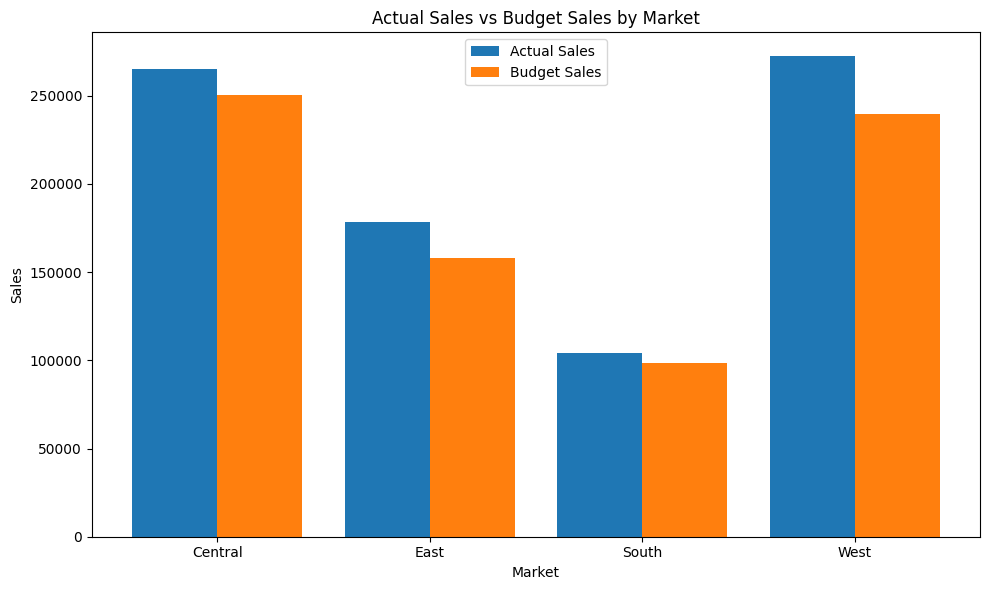

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

x = range(len(market_sales))

plt.bar(
    [i - 0.2 for i in x],
    market_sales["Actual_Sales"],
    width=0.4,
    label="Actual Sales"
)

plt.bar(
    [i + 0.2 for i in x],
    market_sales["Budget_Sales"],
    width=0.4,
    label="Budget Sales"
)

plt.xticks(x, market_sales["Market"])
plt.xlabel("Market")
plt.ylabel("Sales")
plt.title("Actual Sales vs Budget Sales by Market")
plt.legend()
plt.tight_layout()
plt.show()

2. Sales Variance % by Market

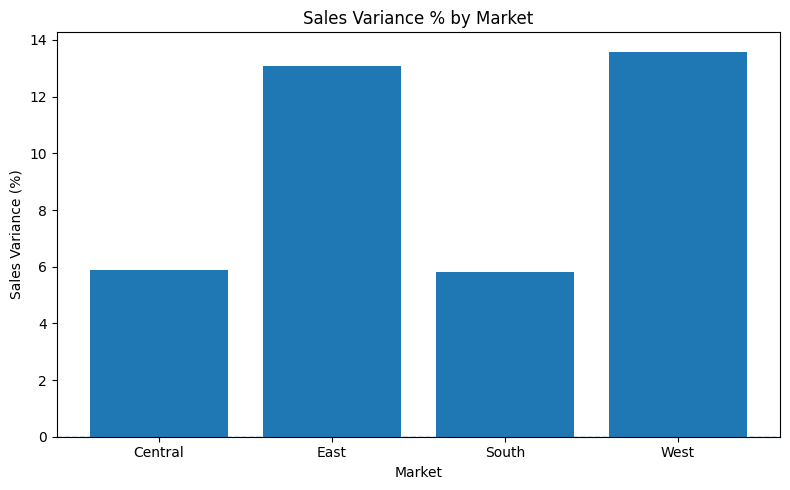

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    market_sales["Market"],
    market_sales["Sales Variance %"]
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Market")
plt.ylabel("Sales Variance (%)")
plt.title("Sales Variance % by Market")
plt.tight_layout()
plt.show()

3. Profit Variance % by Market

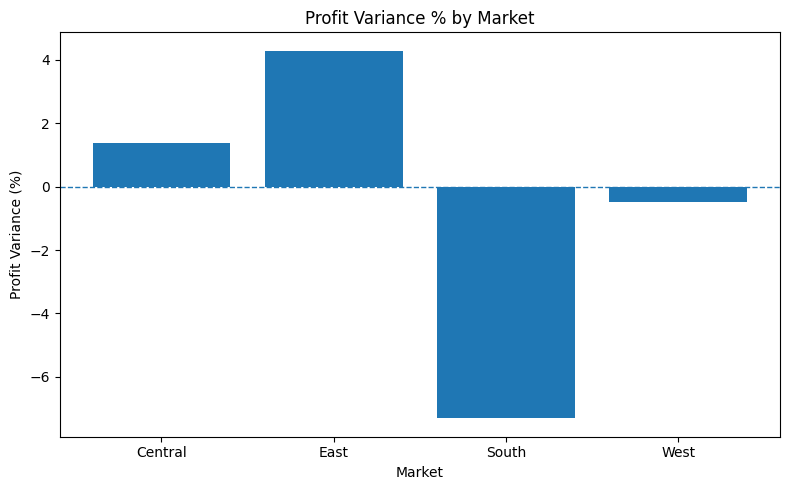

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    market_profit["Market"],
    market_profit["Profit Variance %"]
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Market")
plt.ylabel("Profit Variance (%)")
plt.title("Profit Variance % by Market")
plt.tight_layout()
plt.show()

4. Product Sales Variance

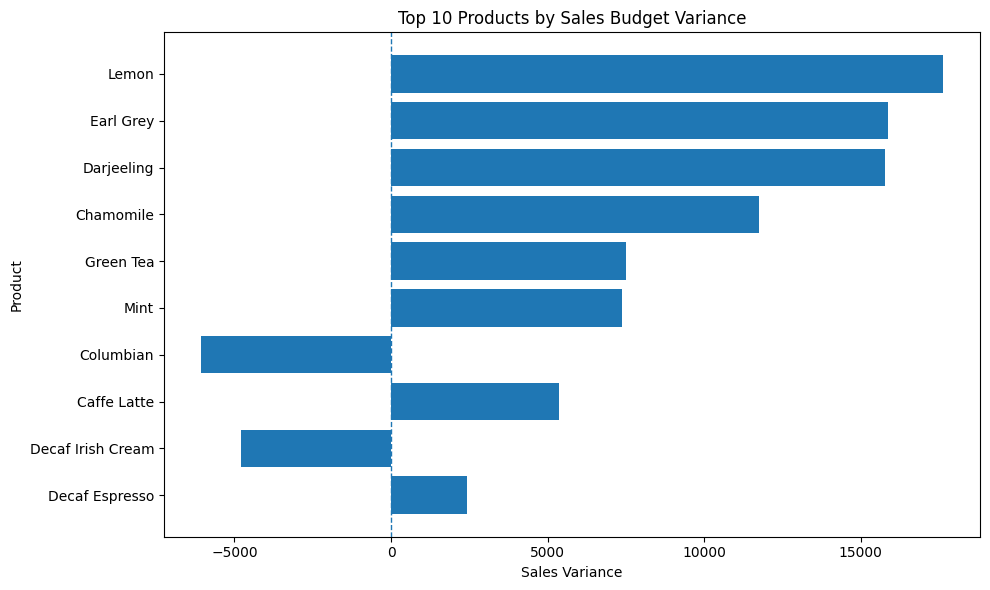

In [24]:
top_products = (
    product_variance
    .assign(
        Absolute_Variance=product_variance["Sales Variance"].abs()
    )
    .sort_values(
        "Absolute_Variance",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products["Product"],
    top_products["Sales Variance"]
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Sales Variance")
plt.ylabel("Product")
plt.title("Top 10 Products by Sales Budget Variance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Final Summary & Business Insights

Step 1 — Overall Budget vs Actual

In [25]:
overall = {
    "Actual Sales": df["Sales"].sum(),
    "Budget Sales": df["Budget Sales"].sum(),
    "Actual Profit": df["Profit"].sum(),
    "Budget Profit": df["Budget Profit"].sum()
}

overall

{'Actual Sales': np.int64(819811),
 'Budget Sales': np.int64(746160),
 'Actual Profit': np.int64(259543),
 'Budget Profit': np.int64(258760)}

In [26]:
overall_sales_variance = (
    df["Sales"].sum() - df["Budget Sales"].sum()
)

overall_sales_variance_pct = (
    overall_sales_variance / df["Budget Sales"].sum()
) * 100

overall_profit_variance = (
    df["Profit"].sum() - df["Budget Profit"].sum()
)

overall_profit_variance_pct = (
    overall_profit_variance / df["Budget Profit"].sum()
) * 100

print("Overall Sales Variance:", round(overall_sales_variance, 2))
print("Overall Sales Variance %:", round(overall_sales_variance_pct, 2), "%")
print("Overall Profit Variance:", round(overall_profit_variance, 2))
print("Overall Profit Variance %:", round(overall_profit_variance_pct, 2), "%")

Overall Sales Variance: 73651
Overall Sales Variance %: 9.87 %
Overall Profit Variance: 783
Overall Profit Variance %: 0.3 %


Step 2 — Create a clean summary table

In [27]:
final_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Budget Sales",
        "Sales Variance",
        "Sales Variance %",
        "Total Profit",
        "Budget Profit",
        "Profit Variance",
        "Profit Variance %"
    ],
    "Value": [
        df["Sales"].sum(),
        df["Budget Sales"].sum(),
        overall_sales_variance,
        overall_sales_variance_pct,
        df["Profit"].sum(),
        df["Budget Profit"].sum(),
        overall_profit_variance,
        overall_profit_variance_pct
    ]
})

final_summary

,Metric,Value
0,Total Sales,819811.000000
1,Budget Sales,746160.000000
2,Sales Variance,73651.000000
3,Sales Variance %,9.870671
4,Total Profit,259543.000000
5,Budget Profit,258760.000000
6,Profit Variance,783.000000
7,Profit Variance %,0.302597


Step 3 — Save your analysis results

In [28]:
market_sales.to_csv(
    "Day_31_Market_Sales_Variance.csv",
    index=False
)

market_profit.to_csv(
    "Day_31_Market_Profit_Variance.csv",
    index=False
)

product_variance.to_csv(
    "Day_31_Product_Variance.csv",
    index=False
)

final_summary.to_csv(
    "Day_31_Final_Summary.csv",
    index=False
)